In [2]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [3]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset

In [4]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [57]:
config_path = '../config_server.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

task_id = config['dataset_kwargs']['task_id']
data_path = config['dataset_kwargs']['data_path']

In [58]:
seqs, ts, cs = get_single_task_dataset(task_id, data_path, split=False)

In [59]:
horizons = [100,
            jnp.quantile(ts, .25).astype(jnp.int32).item(),
            jnp.median(ts).astype(jnp.int32).item(),
            jnp.quantile(ts, .8).astype(jnp.int32).item()]

In [60]:
task_id

6

In [61]:
horizons

[100, 301, 308, 316]

In [62]:
%%time

num_exps = 5

# res2_is = np.zeros((num_exps, len(horizons)))
res2_lm = np.zeros((num_exps, len(horizons)))
# res2_td = np.zeros((num_exps, len(horizons)))

# res3_is = np.zeros((num_exps, len(horizons)))
res3_lm = np.zeros((num_exps, len(horizons)))
# res3_td = np.zeros((num_exps, len(horizons)))

for fold in range(num_exps):
    for i, H in enumerate(horizons):
        
        print(".", end="")
        
        # # Initial state.
        # config['landmark'] = False
        # config['dataset_kwargs']['horizon'] = H
        # model = SA(config, seed=fold)

        # train_gen, test_gen = model.get_train_test()
        # seqs = test_gen.X
        # ts = test_gen.ts
        # cs = test_gen.cs
        
        # _ = model.train(train_gen, test_gen)
        # res2_is[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        # beta = model.state.params['cox_linear_model']['beta']
        # scores = score(beta, seqs[:, 0])
        # res3_is[fold, i] = concordance_index(scores, ts, cs)

        # del model
        
        # Landmarking.
        config['landmark'] = True
        config['dataset_kwargs']['horizon'] = H
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test()
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_lm[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)

        del model
        
    print()

....
....
....
....
....
CPU times: user 29min 48s, sys: 6min 33s, total: 36min 22s
Wall time: 12h 30min 1s


In [63]:
res3_lm

array([[0.98313339, 0.24706266, 0.2735369 , 0.38262477],
       [0.98505489, 0.23381643, 0.30143113, 0.30062112],
       [0.97558474, 0.20874248, 0.29617164, 0.42504627],
       [0.98300654, 0.2289502 , 0.27415254, 0.47206529],
       [0.98354444, 0.26233852, 0.26132246, 0.33090468]])

In [47]:
mean

array([0., 0., 0., 0., 0., 0.])

Text(0.5, 0, 'Number of patients')

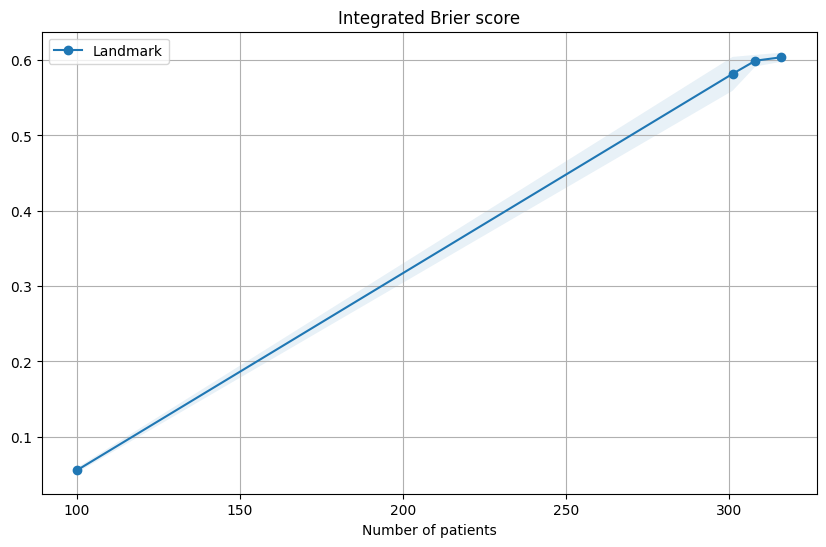

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

res = res2_lm
mean = res.mean(axis=0)
std = res.std(axis=0) #/ np.sqrt(num_exps)
ax.plot(horizons, mean, marker="o", label=label)
ax.fill_between(horizons, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Number of patients")

Text(0.5, 0, 'Number of patients')

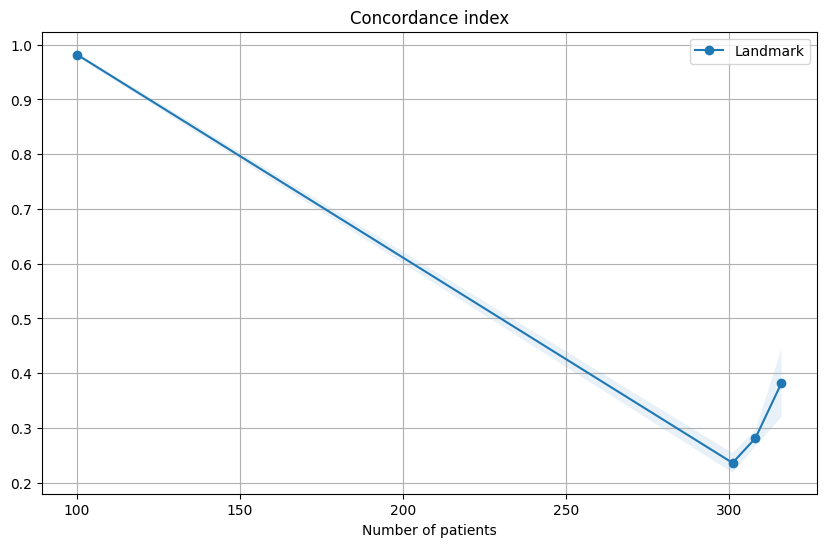

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

res = res3_lm
mean = res.mean(axis=0)
std = res.std(axis=0) #/ np.sqrt(num_exps)
ax.plot(horizons, mean, marker="o", label=label)
ax.fill_between(horizons, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

NameError: name 'agent' is not defined

In [49]:
X_train[0]

Array([[0.        , 0.62823665, 0.65400183, ..., 0.772517  , 0.8502585 ,
        0.8145863 ],
       [0.00251256, 0.5498282 , 0.552334  , ..., 0.64036196, 1.        ,
        1.        ],
       [0.00502513, 0.76637155, 0.7705579 , ..., 0.6067518 , 0.8339199 ,
        0.8254351 ],
       ...,
       [0.8718593 , 0.8334748 , 0.84492046, ..., 0.6329556 , 0.6912598 ,
        0.6676272 ],
       [0.8743719 , 0.866956  , 0.8582654 , ..., 0.6778133 , 0.744893  ,
        0.70386815],
       [0.8768844 , 0.876474  , 0.8631214 , ..., 0.7058735 , 0.7632537 ,
        0.735148  ]], dtype=float32)